# Baseline Estimation

This notebook starts the estimation stage. For now it only does two things:

1. load the prepared quarterly analysis dataset
2. inspect the sample and simple moments

The idea is to keep data construction in notebook `02` and model work in notebook `03`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'data').exists() else CWD.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

## Load Dataset

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
analysis_df.head()

,date,E,U,Y
0,1992-01-01,-0.297662,0.407334,0.570575
1,1992-04-01,-0.146517,0.375318,-0.085709
2,1992-07-01,-1.132308,0.459021,-0.726074
3,1992-10-01,-0.847614,0.586024,-0.501668
4,1993-01-01,-0.839623,0.505504,-0.332376


In [3]:
sample_summary = pd.DataFrame(
    {
        'metric': ['start', 'end', 'observations'],
        'value': [analysis_df['date'].min(), analysis_df['date'].max(), len(analysis_df)],
    }
)
sample_summary

,metric,value
0,start,1992-01-01 00:00:00
1,end,2025-10-01 00:00:00
2,observations,136


## Sample And Simple Moments

In [4]:
moments = analysis_df[['E', 'U', 'Y']].agg(['mean', 'std', 'min', 'median', 'max']).T
moments

,mean,std,min,median,max
E,0.214007,0.409320,-1.666863,0.249565,1.049779
U,0.011255,0.219378,-0.546578,-0.006668,0.893430
Y,0.432183,0.980470,-6.366712,0.525716,6.080447


In [5]:
analysis_df[['E', 'U', 'Y']].corr()

,E,U,Y
E,1.000000,-0.583524,0.543172
U,-0.583524,1.000000,-0.458731
Y,0.543172,-0.458731,1.000000


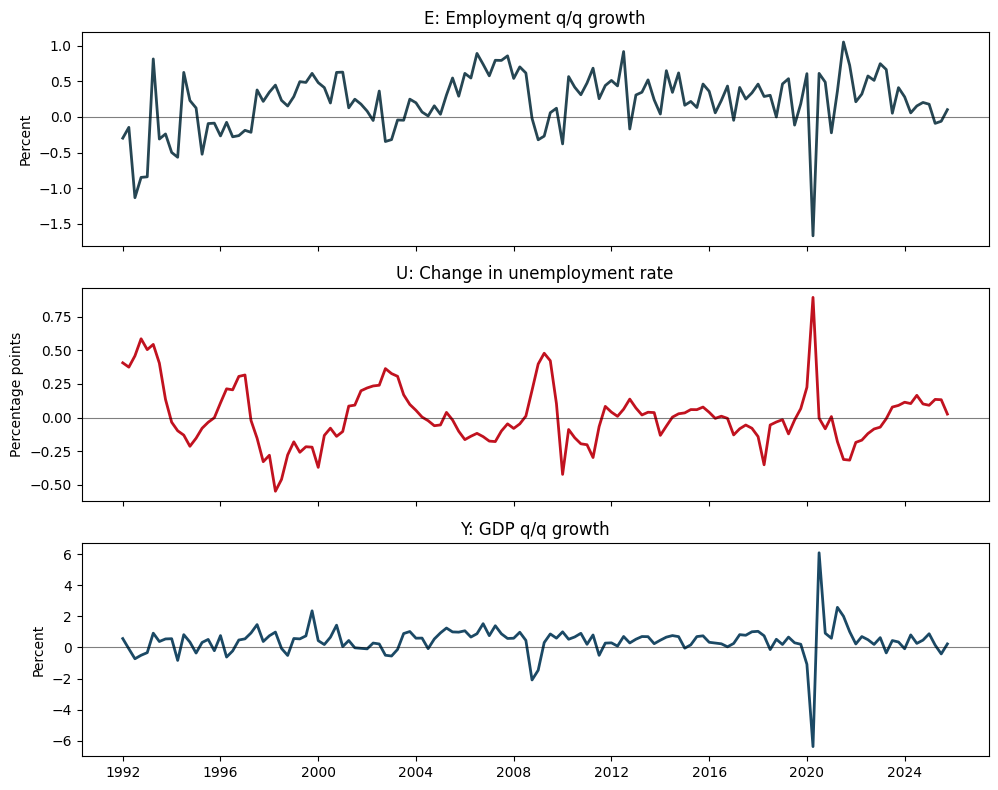

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(analysis_df['date'], analysis_df['E'], color='#264653', linewidth=2)
axes[0].axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axes[0].set_title('E: Employment q/q growth')
axes[0].set_ylabel('Percent')

axes[1].plot(analysis_df['date'], analysis_df['U'], color='#c1121f', linewidth=2)
axes[1].axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axes[1].set_title('U: Change in unemployment rate')
axes[1].set_ylabel('Percentage points')

axes[2].plot(analysis_df['date'], analysis_df['Y'], color='#1b4965', linewidth=2)
axes[2].axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axes[2].set_title('Y: GDP q/q growth')
axes[2].set_ylabel('Percent')

fig.tight_layout()

## U-Y Relation

This section looks at the relationship between unemployment changes and GDP growth. We start with a scatter plot and then estimate a simple OLS regression with current and lagged GDP growth.

In [7]:
import statsmodels.api as sm

Text(0, 0.5, 'U: Change in unemployment rate')

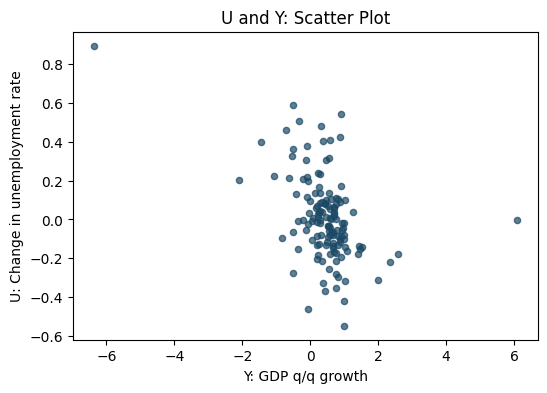

In [8]:
ax = analysis_df.plot.scatter(
    x='Y',
    y='U',
    figsize=(6, 4),
    color='#1b4965',
    alpha=0.7,
    title='U and Y: Scatter Plot',
)
ax.set_xlabel('Y: GDP q/q growth')
ax.set_ylabel('U: Change in unemployment rate')

In [9]:
uy_ols = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
uy_ols['Y_lag1'] = uy_ols['Y'].shift(1)
uy_ols['Y_lag2'] = uy_ols['Y'].shift(2)
uy_ols = uy_ols.dropna().reset_index(drop=True)

X = sm.add_constant(uy_ols[['Y', 'Y_lag1', 'Y_lag2']])
ols_result = sm.OLS(uy_ols['U'], X).fit()
print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      U   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     40.09
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.07e-18
Time:                        09:59:18   Log-Likelihood:                 59.619
No. Observations:                 134   AIC:                            -111.2
Df Residuals:                     130   BIC:                            -99.65
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1235      0.017      7.072      0.0

## U-Y Relation Using IRISpie

This repeats the same regression using IRISpie's `ordinary_least_squares`, with the design matrix arranged in IRISpie's variables-by-observations format.

In [10]:
import irispie as ir
import numpy as np

In [11]:
uy_irispie = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
uy_irispie['Y_lag1'] = uy_irispie['Y'].shift(1)
uy_irispie['Y_lag2'] = uy_irispie['Y'].shift(2)
uy_irispie = uy_irispie.dropna().reset_index(drop=True)

lhs = uy_irispie[['U']].to_numpy().T
rhs = np.vstack([
    np.ones(len(uy_irispie)),
    uy_irispie['Y'].to_numpy(),
    uy_irispie['Y_lag1'].to_numpy(),
    uy_irispie['Y_lag2'].to_numpy(),
])

beta = ir.ordinary_least_squares(lhs, rhs).reshape(-1)
fitted = (beta.reshape(1, -1) @ rhs).reshape(-1)
residuals = uy_irispie['U'].to_numpy() - fitted
nobs = len(uy_irispie)
ncoef = rhs.shape[0]
sigma2 = (residuals @ residuals) / (nobs - ncoef)
vcov = sigma2 * np.linalg.inv(rhs @ rhs.T)
std_err = np.sqrt(np.diag(vcov))
t_stats = beta / std_err
ssr = residuals @ residuals
tss = ((uy_irispie['U'] - uy_irispie['U'].mean()) ** 2).sum()
r2 = 1 - ssr / tss

irispie_results = pd.DataFrame({
    'coefficient': ['const', 'Y', 'Y_lag1', 'Y_lag2'],
    'estimate': beta,
    'std_error': std_err,
    't_stat': t_stats,
})
irispie_results

,coefficient,estimate,std_error,t_stat
0,const,0.123490,0.017461,7.072379
1,Y,-0.108663,0.013861,-7.839286
2,Y_lag1,-0.091921,0.013860,-6.631881
3,Y_lag2,-0.070142,0.013889,-5.050343


In [12]:
pd.DataFrame({
    'metric': ['observations', 'r_squared', 'residual_std_error'],
    'value': [nobs, r2, np.sqrt(sigma2)],
})

,metric,value
0,observations,134.000000
1,r_squared,0.480537
2,residual_std_error,0.157441


## ARDL-Style Extension

This extends the baseline regression by adding a lag of `U`, while keeping current and lagged `Y` terms.

In [13]:
ardl_df = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
ardl_df['U_lag1'] = ardl_df['U'].shift(1)
ardl_df['Y_lag1'] = ardl_df['Y'].shift(1)
ardl_df['Y_lag2'] = ardl_df['Y'].shift(2)
ardl_df = ardl_df.dropna().reset_index(drop=True)

X_ardl = sm.add_constant(ardl_df[['U_lag1', 'Y', 'Y_lag1', 'Y_lag2']])
ardl_result = sm.OLS(ardl_df['U'], X_ardl).fit()
print(ardl_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      U   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     133.2
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           8.22e-45
Time:                        09:59:18   Log-Likelihood:                 125.30
No. Observations:                 134   AIC:                            -240.6
Df Residuals:                     129   BIC:                            -226.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0549      0.012      4.685      0.0

In [14]:
ardl_compare = pd.DataFrame({
    'metric': ['observations', 'r_squared', 'adj_r_squared', 'aic', 'bic', 'durbin_watson'],
    'baseline_uy': [
        int(ols_result.nobs),
        ols_result.rsquared,
        ols_result.rsquared_adj,
        ols_result.aic,
        ols_result.bic,
        sm.stats.stattools.durbin_watson(ols_result.resid),
    ],
    'ardl_style': [
        int(ardl_result.nobs),
        ardl_result.rsquared,
        ardl_result.rsquared_adj,
        ardl_result.aic,
        ardl_result.bic,
        sm.stats.stattools.durbin_watson(ardl_result.resid),
    ],
})
ardl_compare

,metric,baseline_uy,ardl_style
0,observations,134.000000,134.000000
1,r_squared,0.480537,0.805112
2,adj_r_squared,0.468549,0.799069
3,aic,-111.237634,-240.607525
4,bic,-99.646275,-226.118326
5,durbin_watson,0.585421,1.921527


## Implied Break-Even GDP Growth Rate

For both specifications, the break-even GDP growth rate is the common growth rate `Y*` that makes unemployment changes equal to zero in steady state.

In [15]:
from pathlib import Path
import pandas as pd
import statsmodels.api as sm

if 'DATA_PATH' not in globals():
    CWD = Path.cwd().resolve()
    PROJECT_ROOT = CWD if (CWD / 'data').exists() else CWD.parent
    DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'

if 'analysis_df' not in globals():
    analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date'])

if 'ols_result' not in globals():
    uy_ols = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
    uy_ols['Y_lag1'] = uy_ols['Y'].shift(1)
    uy_ols['Y_lag2'] = uy_ols['Y'].shift(2)
    uy_ols = uy_ols.dropna().reset_index(drop=True)
    X = sm.add_constant(uy_ols[['Y', 'Y_lag1', 'Y_lag2']])
    ols_result = sm.OLS(uy_ols['U'], X).fit()

if 'ardl_result' not in globals():
    ardl_df = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
    ardl_df['U_lag1'] = ardl_df['U'].shift(1)
    ardl_df['Y_lag1'] = ardl_df['Y'].shift(1)
    ardl_df['Y_lag2'] = ardl_df['Y'].shift(2)
    ardl_df = ardl_df.dropna().reset_index(drop=True)
    X_ardl = sm.add_constant(ardl_df[['U_lag1', 'Y', 'Y_lag1', 'Y_lag2']])
    ardl_result = sm.OLS(ardl_df['U'], X_ardl).fit()

beta_sum_simple = ols_result.params['Y'] + ols_result.params['Y_lag1'] + ols_result.params['Y_lag2']
break_even_simple_qoq = -ols_result.params['const'] / beta_sum_simple
break_even_simple_annualized = ((1 + break_even_simple_qoq / 100) ** 4 - 1) * 100

beta_sum_ardl = ardl_result.params['Y'] + ardl_result.params['Y_lag1'] + ardl_result.params['Y_lag2']
break_even_ardl_qoq = -ardl_result.params['const'] / beta_sum_ardl
break_even_ardl_annualized = ((1 + break_even_ardl_qoq / 100) ** 4 - 1) * 100

break_even_compare = pd.DataFrame({
    'specification': ['simple distributed-lag', 'ardl-style'],
    'const_term': [ols_result.params['const'], ardl_result.params['const']],
    'sum_y_coefficients': [beta_sum_simple, beta_sum_ardl],
    'implied_break_even_growth_qoq_pct': [break_even_simple_qoq, break_even_ardl_qoq],
    'implied_break_even_growth_annualized_pct': [break_even_simple_annualized, break_even_ardl_annualized],
})
break_even_compare

,specification,const_term,sum_y_coefficients,implied_break_even_growth_qoq_pct,implied_break_even_growth_annualized_pct
0,simple distributed-lag,0.123490,-0.270725,0.456145,1.837104
1,ardl-style,0.054872,-0.126738,0.432954,1.743096


## COVID Pulse Dummies

We test two pulse dummies, one for `2020 Q2` and one for `2020 Q3`, in both the simple distributed-lag model and the ARDL-style model. The goal is to see whether the extreme collapse and rebound quarters materially change fit, slope estimates, and the implied break-even relationship.

In [16]:
from pathlib import Path
import pandas as pd
import statsmodels.api as sm

if 'DATA_PATH' not in globals():
    CWD = Path.cwd().resolve()
    PROJECT_ROOT = CWD if (CWD / 'data').exists() else CWD.parent
    DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'

if 'analysis_df' not in globals():
    analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)

if 'ols_result' not in globals():
    uy_ols = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
    uy_ols['Y_lag1'] = uy_ols['Y'].shift(1)
    uy_ols['Y_lag2'] = uy_ols['Y'].shift(2)
    uy_ols = uy_ols.dropna().reset_index(drop=True)
    X = sm.add_constant(uy_ols[['Y', 'Y_lag1', 'Y_lag2']])
    ols_result = sm.OLS(uy_ols['U'], X).fit()

if 'ardl_result' not in globals():
    ardl_df = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
    ardl_df['U_lag1'] = ardl_df['U'].shift(1)
    ardl_df['Y_lag1'] = ardl_df['Y'].shift(1)
    ardl_df['Y_lag2'] = ardl_df['Y'].shift(2)
    ardl_df = ardl_df.dropna().reset_index(drop=True)
    X_ardl = sm.add_constant(ardl_df[['U_lag1', 'Y', 'Y_lag1', 'Y_lag2']])
    ardl_result = sm.OLS(ardl_df['U'], X_ardl).fit()

dummy_df = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
dummy_df['Y_lag1'] = dummy_df['Y'].shift(1)
dummy_df['Y_lag2'] = dummy_df['Y'].shift(2)
dummy_df['U_lag1'] = dummy_df['U'].shift(1)
dummy_df['d2020q2'] = (dummy_df['date'] == pd.Timestamp('2020-04-01')).astype(int)
dummy_df['d2020q3'] = (dummy_df['date'] == pd.Timestamp('2020-07-01')).astype(int)
dummy_df = dummy_df.dropna().reset_index(drop=True)

X_simple_dummy = sm.add_constant(dummy_df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ols_dummy_result = sm.OLS(dummy_df['U'], X_simple_dummy).fit()

X_ardl_dummy = sm.add_constant(dummy_df[['U_lag1', 'Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ardl_dummy_result = sm.OLS(dummy_df['U'], X_ardl_dummy).fit()

fit_compare = pd.DataFrame({
    'specification': [
        'simple no dummies',
        'simple + covid pulses',
        'ardl no dummies',
        'ardl + covid pulses',
    ],
    'nobs': [ols_result.nobs, ols_dummy_result.nobs, ardl_result.nobs, ardl_dummy_result.nobs],
    'r_squared': [ols_result.rsquared, ols_dummy_result.rsquared, ardl_result.rsquared, ardl_dummy_result.rsquared],
    'adj_r_squared': [ols_result.rsquared_adj, ols_dummy_result.rsquared_adj, ardl_result.rsquared_adj, ardl_dummy_result.rsquared_adj],
    'aic': [ols_result.aic, ols_dummy_result.aic, ardl_result.aic, ardl_dummy_result.aic],
    'bic': [ols_result.bic, ols_dummy_result.bic, ardl_result.bic, ardl_dummy_result.bic],
    'durbin_watson': [
        sm.stats.stattools.durbin_watson(ols_result.resid),
        sm.stats.stattools.durbin_watson(ols_dummy_result.resid),
        sm.stats.stattools.durbin_watson(ardl_result.resid),
        sm.stats.stattools.durbin_watson(ardl_dummy_result.resid),
    ],
})
fit_compare

coef_compare = pd.DataFrame({
    'specification': ['simple + covid pulses', 'ardl + covid pulses'],
    'd2020q2_coef': [ols_dummy_result.params['d2020q2'], ardl_dummy_result.params['d2020q2']],
    'd2020q2_tstat': [ols_dummy_result.tvalues['d2020q2'], ardl_dummy_result.tvalues['d2020q2']],
    'd2020q3_coef': [ols_dummy_result.params['d2020q3'], ardl_dummy_result.params['d2020q3']],
    'd2020q3_tstat': [ols_dummy_result.tvalues['d2020q3'], ardl_dummy_result.tvalues['d2020q3']],
    'sum_y_coefficients': [
        ols_dummy_result.params['Y'] + ols_dummy_result.params['Y_lag1'] + ols_dummy_result.params['Y_lag2'],
        ardl_dummy_result.params['Y'] + ardl_dummy_result.params['Y_lag1'] + ardl_dummy_result.params['Y_lag2'],
    ],
})
coef_compare

print(ols_dummy_result.summary())
print(ardl_dummy_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      U   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     24.40
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           3.42e-17
Time:                        09:59:18   Log-Likelihood:                 60.591
No. Observations:                 134   AIC:                            -109.2
Df Residuals:                     128   BIC:                            -91.79
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1260      0.019      6.556      0.0